# Optional Lab: Linear Regression using Scikit-Learn

There is an open-source, commercially usable machine learning toolkit called [scikit-learn](https://scikit-learn.org/stable/index.html). This toolkit contains implementations of many of the algorithms that you will work with in this course.

### Goals
In this lab you will:
- Utilize  scikit-learn to implement linear regression using Gradient Descent

### Tools
You will utilize functions from scikit-learn as well as matplotlib and NumPy. 

In [2]:
from pathlib import Path
import sys

start_dir = Path.cwd().resolve()

candidate_utils_dirs = []
for base in [start_dir, *list(start_dir.parents)[:8]]:
    candidate_utils_dirs.append(base / "utils")
    candidate_utils_dirs.append(base / "deeplearning.ai" / "labs" / "machine-learning-specialization" / "utils")

utils_dir = next((p for p in candidate_utils_dirs if p.is_dir()), None)

if utils_dir is None:
    search_root = next((b for b in [start_dir, *list(start_dir.parents)[:8]] if (b / "deeplearning.ai").is_dir()), None)
    if search_root is not None:
        matches = list((search_root / "deeplearning.ai").rglob("lab_utils_multi.py"))
        if matches:
            utils_dir = matches[0].parent

if utils_dir is None:
    tried = [str(p) for p in candidate_utils_dirs[:6]]
    raise FileNotFoundError(
        "Could not find the course utils folder (containing lab_utils_multi.py). "
        f"Tried (examples): {tried} (and a bounded search under a parent containing 'deeplearning.ai'). "
        f"Start dir: {start_dir}"
    )

utils_path = str(utils_dir)
if utils_path not in sys.path:
    sys.path.append(utils_path)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_multi import load_house_data
from lab_utils_common import dlc
np.set_printoptions(precision=2)
plt.style.use('../utils/deeplearning.mplstyle')

---

## Gradient Descent
Scikit-learn has a gradient descent regression model [sklearn.linear_model.SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#examples-using-sklearn-linear-model-sgdregressor).  Like your previous implementation of gradient descent, this model performs best with normalized inputs. [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) will perform z-score normalization as in a previous lab. Here it is referred to as 'standard score'.

### Load the data set


In [5]:
x_train, y_train = load_house_data()
x_features = ['size(sqft)','bedrooms','floors','age']

### Scale/normalize the training data

In [6]:
scaler = StandardScaler()
x_norm = scaler.fit_transform(x_train)
print(f"Peak to Peak range by column in Raw         X:{np.ptp(x_train, axis=0)}")
print(f"Peak to Peak range by column in Normalized  X:{np.ptp(x_norm, axis=0)}")

Peak to Peak range by column in Raw         X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized  X:[5.85 6.14 2.06 3.69]


### Create and fit the regression model

In [7]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(x_norm, y_train)
print(sgdr)
print(f"Num of iterations completed: {sgdr.n_iter_}, number of weight update: {sgdr.t_}")

SGDRegressor()
Num of iterations completed: 116, number of weight update: 11485.0


### View parameters

Note, the parameters are associated with the *normalized* input data. The fir parameters are very close to those found in the previous lab with this data.

In [8]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"Model parameters:                         w: {w_norm}, b: {b_norm}")
print(f"Model parameter from previous cell:       w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

Model parameters:                         w: [109.99 -21.   -32.39 -38.06], b: [363.16]
Model parameter from previous cell:       w: [110.56 -21.27 -32.71 -37.97], b: 363.16


### Make predictions
Predict the targets of the training data. Use both the `predict` routine and compute using $w$ and $b$.

In [10]:
# Make predictions using sgdr.predict()
y_pred_sgd = sgdr.predict(x_norm)

# Make predictions using w and b
y_pred = np.dot(x_norm, w_norm) + b_norm

print(f"Prediction using np.dot() and sgdr.predict() match: {(y_pred == y_pred_sgd).all()}\n")
print(f"Prediction on training set: \n{y_pred[:4]}\n")
print(f"Target values \n{y_train[:4]}")

Prediction using np.dot() and sgdr.predict() match: True

Prediction on training set: 
[295.2  485.84 389.6  492.  ]

Target values 
[300.  509.8 394.  540. ]


### Plot Results

Let's plot the predictions vs. the target values.

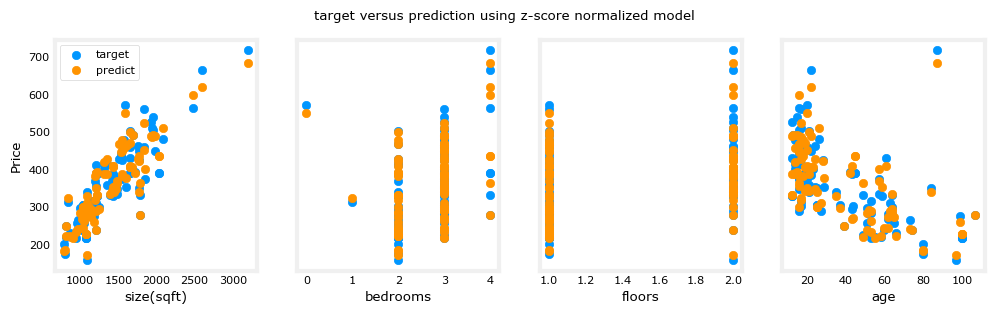

In [11]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(x_features[i])
    ax[i].scatter(x_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()